## Assignment 3: $k$ Nearest Neighbor


**Q1.**
1. What is the difference between regression and classification?
2. What is a confusion table? What does it help us understand about a model's performance?
3. What does the SSE quantify about a particular model?
4. What are overfitting and underfitting? 
5. Why does splitting the data into training and testing sets, and choosing $k$ by evaluating accuracy or SSE on the test set, improve model performance?
6. With classification, we can report a class label as a prediction or a probability distribution over class labels. Please explain the strengths and weaknesses of each approach.

**Q2.** This is a case study on $k$ nearest neighbor classification, using the `land_mines.csv` data.

The data consists of a label, `mine_type`, taking integer values 1 to 5, and three properties of the mine, `voltage`, `height` and `soil`. We want to predict the kind of mine from data about it. Imagine working for the DOD or a humanitarian aid agency, trying to help people remove land mines more safely.

1. Load the data. Perform some EDA, summarizing the target label and the features.
2. Split the sample 50/50 into training and test/validation sets. (The smaller the data are, the more equal the split should be, in my experience: Otherwise, all of the members of one class end up in the training or test data, and the model falls apart.)
3. Build a $k$-NN classifier. Explain how you select $k$.
4. Print a confusion table for the optimal model, comparing predicted and actual class label on the test set. How accurate is it? Where is performance more or less accurate?
5. Notice that you can have a lot of accurate predictions for a given type of mine, but still make a lot of mistakes. Please explain how you'd advise someone to actually use this predictive model in practice, given the errors that it tends to make.

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Leyton Allen

**Date:** 10/1/2026

Q1.

1. Regression vs. Classification

Regression is used when we are trying to predict a number. Classification is used when we are trying to predict a category or group. For example, predicting someones salary would be regression. Predicting whether an email is spam would be classification.

2. Confusion Table

A confusion table compares the actual results to what the model predicted. It shows how many predictions were correct. It also shows which groups the model confused with each other. This helps us see where the model is doing well and where it is making mistakes.

3. SSE

SSE = Sum of Squared Errors. It measures how far the models predictions are from the actual values. Smaller SSE usually means the models predictions are closer to the real values.

4. Overfitting and Underfitting

Overfitting is when a model learns the data too well and does not work as well on new data. Underfitting is when the model is too simple and does not fit the data very well either.

5. Training and Testing Data

Splitting the data lets us train the model on one group and test it on data it has not seen before. We can try different values of k and compare how accurate they are. This helps us choose a k that works better on new data instead of only working well on the training data.

6. Class Labels vs. Probability Predictions

A class label gives one final prediction, which makes it simple and easy to understand. The downside is that it does not show how confident the model is.

A probability prediction gives the probability for each possible class. This gives us more information about how confident the model is, but it can be a little harder to understand than just one class label.

Q2.

In [27]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [28]:
df = pd.read_csv("data/land_mines.csv")

df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [29]:
df.shape

(338, 4)

In [30]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 338 entries, 0 to 337
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   voltage    338 non-null    float64
 1   height     338 non-null    float64
 2   soil       338 non-null    float64
 3   mine_type  338 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 10.7 KB


In [31]:
df.describe()

,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


In [32]:
df["mine_type"].value_counts().sort_index()

mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64

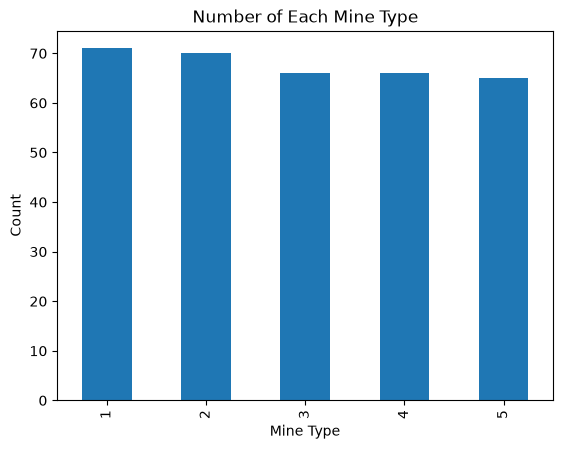

In [33]:
df["mine_type"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Mine Type")
plt.ylabel("Count")
plt.title("Number of Each Mine Type")
plt.show()

The dataset contains the target variable mine_type and three features (voltage, height, and soil). As you can see in the chart, there are five mine types. I looked at the number of observations in each class and the summary statistics for the features. The features are measured on pretty similar scales.

In [34]:
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

In [35]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=1,
    stratify=y
)

In [36]:
print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 169
Testing size: 169


In [37]:
print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())

mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64


In [38]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)

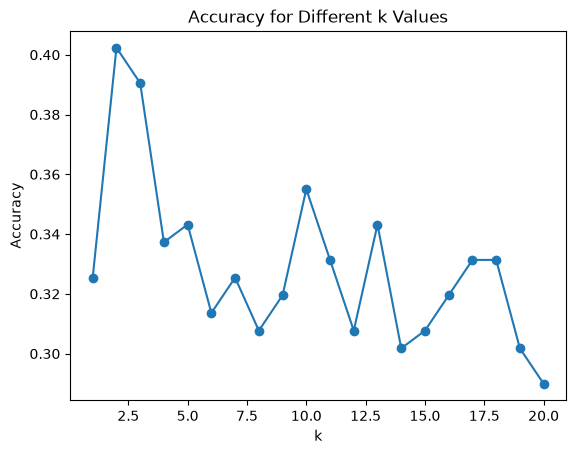

In [39]:
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy for Different k Values")
plt.show()

In [40]:
best_accuracy = max(accuracies)
best_k = k_values[accuracies.index(best_accuracy)]

print("Best k:", best_k)
print("Best accuracy:", round(best_accuracy * 100, 2), "%")

Best k: 2
Best accuracy: 40.24 %


I tested values of k from 1 to 20. For each k, I trained the model on the training data and calculated its accuracy on the test data. I selected the k with the highest test accuracy.

In [41]:
final_model = KNeighborsClassifier(n_neighbors=best_k)

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

In [42]:
confusion_table = pd.crosstab(
    y_test,
    final_predictions,
    rownames=["Actual"],
    colnames=["Predicted"]
)

confusion_table

Predicted,1,2,3,4,5
Actual,,,,,
1,18,1,12,3,1
2,0,29,1,5,0
3,7,1,16,8,1
4,15,5,10,3,0
5,14,1,14,2,2


In [43]:
final_accuracy = accuracy_score(y_test, final_predictions)

print("Final accuracy:", round(final_accuracy * 100, 2), "%")

Final accuracy: 40.24 %


In [44]:
for mine_type in sorted(y_test.unique()):
    actual_type = y_test == mine_type

    type_accuracy = accuracy_score(
        y_test[actual_type],
        final_predictions[actual_type]
    )

    print(
        "Mine type",
        mine_type,
        "accuracy:",
        round(type_accuracy * 100, 2),
        "%"
    )

Mine type 1 accuracy: 51.43 %
Mine type 2 accuracy: 82.86 %
Mine type 3 accuracy: 48.48 %
Mine type 4 accuracy: 9.09 %
Mine type 5 accuracy: 6.06 %


The final model had an accuracy of 40.24%. Mine type 2 had the highest accuracy at 82.86%. Mine types 4 and 5 had the lowest accuracy at 9.09% and 6.06%. Looking at the confusion table, mine type 4 was often predicted as type 1 or type 3. Along with that, mine type 5 was also often predicted as type 1 or type 3. This shows that the model works much better for some mine types than others.

I would not use this model by itself to make important safety decisions. The overall accuracy is fairly low and the model has a lot of trouble predicting mine types 4 and 5. It could still be useful as another source of information, but the prediction should be checked using other information or by an expert. This is especially important with land mines because a wrong prediction could be dangerous.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 135f714
- **AI tool and model used:** ChatGPT, GPT-5.6 Sol

### *Prompts used

“Check my Q1 answers and tell me what I should fix.”

“Check my k-NN code and tell me if anything is wrong.”

“Help me improve my explanation of the confusion table.”

“Help me explain which mine types the model predicts best and worst.”

“Help me improve my final recommendation for using the model.”

### *AI-proposed changes


1. Make the Q1 answer about training and testing more accurate by explaining that choosing k using the same test set many times can cause the model to fit that test set too closely.

2. Add a little more EDA by showing the distributions of voltage, height, and soil.

3. Make the confusion table explanation more specific by saying which mine types are confused with each other.

4. Add the accuracy for each mine type so it is easier to see where the model performs best and worst.

5. Make the final recommendation clearer by explaining that the model should not be used by itself because its overall accuracy is low and it performs very poorly on some mine types.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | Accept | This makes the explanation more accurate. I checked that repeatedly using the same test set to choose k can affect how well we judge the model. |
| 2 | Accept | I added simple histograms for the three features and checked their distributions. |
| 3 | Accept | I looked at the confusion table and saw that mine types 4 and 5 were often predicted as types 1 or 3. |
| 4 | Accept | I calculated the accuracy for each mine type and saw that the model performed much better on some types than others. |
| 5 | Accept | The overall accuracy was only 40.24%, and mine types 4 and 5 had very low accuracy, so the model should not be used alone. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

## Q1

### 1. Regression vs. Classification

Regression is used when we are trying to predict a number. Classification is used when we are trying to predict a category or group. For example, predicting someone's salary would be regression, while predicting whether an email is spam would be classification.

### 2. Confusion Table

A confusion table compares the actual results to what the model predicted. It shows how many predictions were correct and which groups the model confused with each other. This helps us see where the model is doing well and where it is making mistakes.

### 3. SSE

SSE stands for Sum of Squared Errors. It measures how far the model's predictions are from the actual values. A smaller SSE usually means the model's predictions are closer to the real values.

### 4. Overfitting and Underfitting

Overfitting is when a model learns the training data too closely and does not work as well on new data. Underfitting is when the model is too simple and does not fit the training data very well either.

### 5. Training and Testing Data

Splitting the data lets us train the model on one group and test it on data it has not seen before. We can try different values of k and compare their performance. One issue is that if we keep choosing k using the same test set, we may start fitting the model too much to that test set. Normally, a separate validation set or cross-validation would help avoid this.

### 6. Class Labels vs. Probability Predictions

A class label gives one final prediction, which makes it simple and easy to understand. The downside is that it does not show how confident the model is.

A probability prediction gives the probability for each possible class. This gives us more information about how confident the model is, but it can be a little harder to understand than just one class label.

## Q2

In [45]:
import os
os.chdir(r"C:\Users\leyto\A03-knn")
print(os.getcwd())

C:\Users\leyto\A03-knn


In [46]:
import os
os.chdir(r"C:\Users\leyto\A03-knn")
print(os.getcwd())

C:\Users\leyto\A03-knn


In [47]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

df = pd.read_csv("data/land_mines.csv")

df.head()

,voltage,height,soil,mine_type
0,0.338157,0.000000,0.0,1
1,0.320241,0.181818,0.0,1
2,0.287009,0.272727,0.0,1
3,0.256284,0.454545,0.0,1
4,0.262840,0.545455,0.0,1


In [48]:
print(df.shape)
display(df.describe())
print(df["mine_type"].value_counts().sort_index())

(338, 4)


,voltage,height,soil,mine_type
count,338.000000,338.000000,338.000000,338.000000
mean,0.430634,0.508876,0.503550,2.952663
std,0.195819,0.306043,0.344244,1.419703
min,0.197734,0.000000,0.000000,1.000000
25%,0.309737,0.272727,0.200000,2.000000
50%,0.359516,0.545455,0.600000,3.000000
75%,0.482628,0.727273,0.800000,4.000000
max,0.999999,1.000000,1.000000,5.000000


mine_type
1    71
2    70
3    66
4    66
5    65
Name: count, dtype: int64


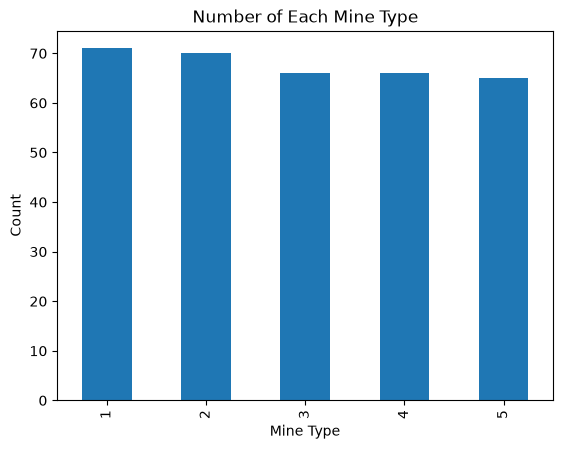

In [49]:
df["mine_type"].value_counts().sort_index().plot(kind="bar")

plt.xlabel("Mine Type")
plt.ylabel("Count")
plt.title("Number of Each Mine Type")
plt.show()

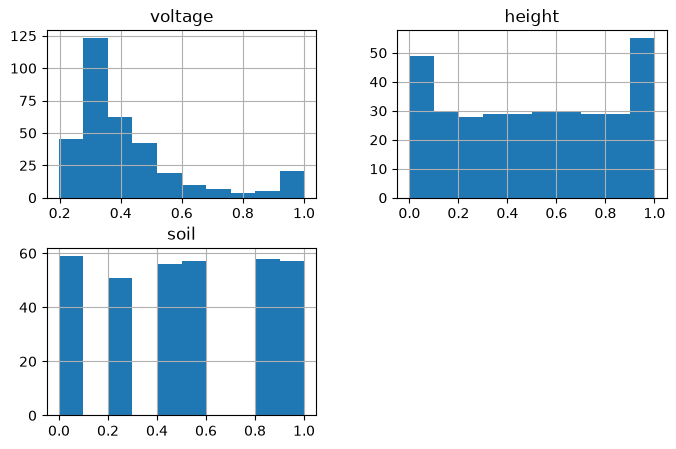

In [50]:
df[["voltage", "height", "soil"]].hist(figsize=(8, 5))
plt.show()

The dataset has 338 observations. The target variable is `mine_type` and the three features are `voltage`, `height`, and `soil`. There are five mine types and the number of observations in each type is fairly similar. I also looked at the summary statistics and the distributions of the three features. The features are measured on fairly similar scales.

In [51]:
X = df[["voltage", "height", "soil"]]
y = df["mine_type"]

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.5,
    random_state=1,
    stratify=y
)

print("Training size:", len(X_train))
print("Testing size:", len(X_test))

Training size: 169
Testing size: 169


In [53]:
print(y_train.value_counts().sort_index())
print(y_test.value_counts().sort_index())

mine_type
1    36
2    35
3    33
4    33
5    32
Name: count, dtype: int64
mine_type
1    35
2    35
3    33
4    33
5    33
Name: count, dtype: int64


In [54]:
k_values = range(1, 21)
accuracies = []

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    accuracies.append(accuracy)

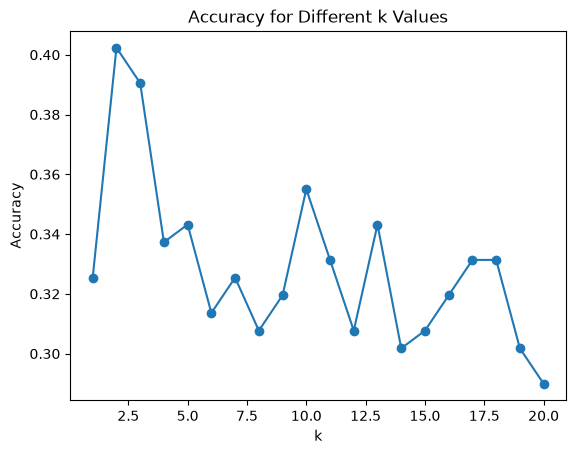

In [55]:
plt.plot(k_values, accuracies, marker="o")
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Accuracy for Different k Values")
plt.show()

In [56]:
best_accuracy = max(accuracies)
best_k = k_values[accuracies.index(best_accuracy)]

print("Best k:", best_k)
print("Best accuracy:", round(best_accuracy * 100, 2), "%")

Best k: 2
Best accuracy: 40.24 %


I tested values of k from 1 to 20. For each value I trained the k-NN model using the training data and checked its accuracy on the test data. The highest accuracy came from k = 2. With that, I used k = 2 for the final model.

In [57]:
final_model = KNeighborsClassifier(n_neighbors=best_k)

final_model.fit(X_train, y_train)

final_predictions = final_model.predict(X_test)

In [58]:
confusion_table = pd.crosstab(
    y_test,
    final_predictions,
    rownames=["Actual"],
    colnames=["Predicted"]
)

confusion_table

Predicted,1,2,3,4,5
Actual,,,,,
1,18,1,12,3,1
2,0,29,1,5,0
3,7,1,16,8,1
4,15,5,10,3,0
5,14,1,14,2,2


In [59]:
final_accuracy = accuracy_score(y_test, final_predictions)

print("Final accuracy:", round(final_accuracy * 100, 2), "%")

Final accuracy: 40.24 %


In [60]:
for mine_type in sorted(y_test.unique()):
    actual_type = y_test == mine_type

    type_accuracy = accuracy_score(
        y_test[actual_type],
        final_predictions[actual_type]
    )

    print(
        "Mine type",
        mine_type,
        "accuracy:",
        round(type_accuracy * 100, 2),
        "%"
    )

Mine type 1 accuracy: 51.43 %
Mine type 2 accuracy: 82.86 %
Mine type 3 accuracy: 48.48 %
Mine type 4 accuracy: 9.09 %
Mine type 5 accuracy: 6.06 %


The final model had accuracy of 40.24%. Mine type 2 had the highest accuracy at 82.86%. Mine types 4 and 5 had the lowest accuracy at 9.09% and 6.06%. Looking at the confusion table, mine types 4 and 5 were often predicted as mine type 1 or mine type 3. This shows that the model works much better for some mine types than others.

I would not use this model by itself to make important safety decisions. The overall accuracy is only 40.24%, and the model has a lot of trouble predicting mine types 4 and 5. It could still be useful as another source of information, but the prediction should be checked using other information or by an expert. This is especially important because a wrong land mine prediction could be dangerous.

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

The main thing I improved in Phase 2 was making my answers more clear and specific. I added more EDA by looking at the feature distributions and I also checked the accuracy for each mine type instead of only looking at the overall accuracy. This made it easier to see where the model was doing well and where it wasn't.
One issue with the AI suggestions was that I still had to make sure they actually matched my results. I checked the confusion table and the accuracy for each mine type to make sure the explanation was right. I also learned that using the same test set over and over to choose k is not the best way to test a model.
I then verified the changes by rerunning the code and checking the results again. I was able to confirm that the best k was equal to 2 (overall accuracy was 40.24%). I still think the biggest problem is that the model is not very accurate overall. This is especially apparent for mine types 4 and 5. Due to this, I would not use this model by itself for something important like a safety decision.